# Exercises week 38

**FYS-STK3155/4155, fall 2026 — deadline Friday September 18 at midnight.**

## Adaptive learning rates and stochastic gradient descent

The aim this week is that you extend last week's gradient descent code with
the adaptive methods AdaGrad, RMSProp and Adam, that you understand what each
of them does to the step and why their learning rate is not the learning rate
of plain gradient descent, and that you replace the full gradient by a
minibatch gradient with epochs and a learning-rate schedule. Everything here is
reused directly in parts f) and h) of Project 1. The code developed in the
Tuesday session (`week38tuesday.ipynb`, Cases 1 and 2) is meant to be reused,
and the Monday notebook (`week38.ipynb`) contains worked examples of every
piece.

After completing these exercises you will have

* derived the bias correction of Adam and the first step of the adaptive
  methods, and shown why they are insensitive to the scale of a feature;
* your own implementation of AdaGrad, RMSProp and Adam in the same
  three-function structure as last week's gradient descent, checked against
  the closed-form solutions of OLS and Ridge;
* scanned the learning rate for each method and related the windows you find
  to $2/\lambda_{\max}$ (Section 4.5) and to what $\gamma$ means for an
  adaptive method (Sections 4.8–4.12);
* a stochastic gradient descent loop with minibatches, epochs and the
  schedule of Eq. (4.40), and studied the batch size and the schedule
  (Section 4.7);
* applied all of it to the Runge function at degree 10, the problem nothing
  converged on last week.

Reading: Chapter 4, Sections 4.7–4.13 of the book; Goodfellow et al.,
Sections 8.1–8.5.

## The data

We keep last week's function,

$$
f(x) = 2 - x + 5x^2, \qquad x \in [-2, 2],
$$

with $n = 100$ points and Gaussian noise of standard deviation $0.5$, fitted
with polynomial features of degree 2 (an easy problem, $\kappa \approx 1.3$)
and degree 5 (a hard one, $\kappa \approx 520$). As last week, standardise the
columns of the design matrix, centre $\boldsymbol{y}$ and use no intercept
column; the closed-form OLS and Ridge solutions are your reference.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def exercise_data(n=100, degree=2, noise=0.5, seed=2026):
    """Standardised polynomial design matrix (no intercept column) and centred targets."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-2.0, 2.0, n)
    y = 2.0 - x + 5.0 * x**2 + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    return X_norm, y - y.mean()

def runge_data(n=100, degree=10, noise=0.1, seed=2026):
    """Standardised polynomial design matrix for the Runge function, same convention as exercise_data."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1.0, 1.0, n)
    y = 1.0 / (1.0 + 25.0 * x**2) + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    return X_norm, y - y.mean()

def closed_form(X, y, lam=0.0):
    """(X^T X + n lambda I)^-1 X^T y, the 1/n convention of Eq. (3.95)."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)

def cost(theta, X, y, lam=0.0):
    """Eqs. (4.12) and (4.16)."""
    return np.sum((X @ theta - y) ** 2) / len(y) + lam * theta @ theta

def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): your analytical gradient from last week (or jax.grad of cost)."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta

def hessian_eigs(X, lam=0.0):
    n = len(X)
    return np.linalg.eigvalsh((2.0 / n) * X.T @ X + 2.0 * lam * np.eye(X.shape[1]))

X2, y2 = exercise_data(degree=2)
X5, y5 = exercise_data(degree=5)
for X in (X2, X5):
    eigs = hessian_eigs(X)
    print(f"degree {X.shape[1]}: kappa = {eigs.max() / eigs.min():.1f}, 2/lambda_max = {2 / eigs.max():.3f}")

degree 2: kappa = 1.3, 2/lambda_max = 0.894
degree 5: kappa = 520.3, 2/lambda_max = 0.354


## Exercise 1: what the adaptive methods do to the step (analytical)

The three adaptive methods replace the single learning rate $\gamma$ by a
per-coordinate step $\gamma/\sqrt{v_j}$, where $v_j$ estimates the second
moment of the gradient in coordinate $j$ (Section 4.8).

### 1a)

Unroll the RMSProp recursion of Eq. (4.47),
$\boldsymbol{v}_t = \rho\,\boldsymbol{v}_{t-1} + (1-\rho)\boldsymbol{g}_t^2$ with
$\boldsymbol{v}_0 = \boldsymbol{0}$, to obtain Eq. (4.49),
$\boldsymbol{v}_t = (1-\rho)\sum_{j=1}^{t}\rho^{\,t-j}\boldsymbol{g}_j^2$, and show
that the weights sum to $1 - \rho^t$. After how many steps has a gradient's
weight fallen below $1/e$ of its initial weight, for $\rho = 0.9$ and
$\rho = 0.99$? Compare with AdaGrad's sum, Eq. (4.42), whose weights are all
one.

### 1b)

Now Adam. Assume the gradient is stationary with $\mathbb{E}[g^2]$ constant.
Take the expectation of the unrolled second moment of Eq. (4.52) and derive
Eq. (4.53), $\mathbb{E}[v_t] = (1-\beta_2^{\,t})\,\mathbb{E}[g^2]$. Do the same
for the first moment with $\beta_1$. Explain why dividing by $1-\beta_i^t$,
Eq. (4.54), removes the bias exactly, and evaluate the correction factors at
$t = 1$, $t = 10$ and $t = 1000$ for the default $\beta_1 = 0.9$,
$\beta_2 = 0.999$.

### 1c)

Show that the first step of Adam, Eq. (4.55) at $t = 1$, is
$\Delta\theta_j = -\gamma\,\mathrm{sign}(g_{1,j})$ (up to $\epsilon$),
independent of the size of the gradient, and that the same holds for AdaGrad.
What is the first step of RMSProp, which has no bias correction, with
$\rho = 0.99$? What does this tell you about the meaning of $\gamma$ for these
methods, compared with plain gradient descent? Without bias correction, by
what factor would Adam's first step be too long?

### 1d)

Multiply one feature (one column of $\boldsymbol{X}$) by a constant $c$. Show
that the corresponding component of the gradient of the OLS cost scales by
$c$ and that the AdaGrad/RMSProp/Adam step in that coordinate is unchanged,
whereas the plain gradient descent step scales by $c$ (and the stability bound
$2/\lambda_{\max}$ moves). Why does this *not* mean that standardising the
data is unnecessary for the adaptive methods? (Hint: the Tuesday session's
rotated bowl.)

**Answer 1.**

**1a)** Unrolling $\boldsymbol v_t=\rho\boldsymbol v_{t-1}+(1-\rho)\boldsymbol g_t^2$ from $\boldsymbol v_0=\boldsymbol 0$
gives $\boldsymbol v_t=(1-\rho)\sum_{j=1}^t\rho^{\,t-j}\boldsymbol g_j^2$ (each substitution multiplies the
older sum by $\rho$ and adds the new $(1-\rho)g_t^2$ term). The weights $(1-\rho)\rho^{t-j}$ are a
geometric series in $s=t-j$, so $\sum_{j=1}^t(1-\rho)\rho^{t-j}=(1-\rho)\sum_{s=0}^{t-1}\rho^s
=(1-\rho)\frac{1-\rho^t}{1-\rho}=1-\rho^t$.

A gradient $s$ steps in the past carries weight $\propto\rho^s$; it drops below $1/e$ of the
newest weight when $\rho^s=1/e$, i.e. $s=-1/\ln\rho$. That gives $s\approx 9.5$ steps for
$\rho=0.9$ and $s\approx 99.5$ steps for $\rho=0.99$: $\rho$ sets an effective memory window of
about $1/(1-\rho)$ steps. AdaGrad's weights (Eq. 4.42) are all $1$, i.e. it never forgets — every
gradient ever seen counts equally, which is why its effective step keeps shrinking forever
(exercise 2b, 3b).

**1b)** With $\mathbb E[g_j^2]=\mathbb E[g^2]$ constant, taking the expectation of the unrolled
sum in 1a) (with $\rho\to\beta_2$) gives $\mathbb E[v_t]=(1-\beta_2^t)\,\mathbb E[g^2]\sum_{s}\beta_2^s/(1-\beta_2^t)
=(1-\beta_2^t)\,\mathbb E[g^2]$, since the weights already sum to $1-\beta_2^t$. The same
calculation with $g$ instead of $g^2$ and $\beta_1$ gives $\mathbb E[m_t]=(1-\beta_1^t)\,\mathbb E[g]$.
Dividing by $1-\beta_i^t$ removes the bias *exactly* because that factor is exactly the sum of the
weights derived above — it is known analytically at every $t$, unlike an estimated quantity, so
$\hat m_t=m_t/(1-\beta_1^t)$ satisfies $\mathbb E[\hat m_t]=\mathbb E[g]$ with no approximation.

Correction factors $1/(1-\beta_1^t)$ and $1/(1-\beta_2^t)$ for $\beta_1=0.9,\ \beta_2=0.999$:

| $t$ | $1/(1-\beta_1^t)$ | $1/(1-\beta_2^t)$ |
|---|---|---|
| 1 | 10.00 | 1000.0 |
| 10 | 1.54 | 100.5 |
| 1000 | 1.00 | 1.58 |

At $t=1$ the raw moments are strongly biased toward zero (by a factor of $10$ and $1000$
respectively); by $t=1000$ both corrections have decayed to essentially $1$.

**1c)** At $t=1$: $m_1=(1-\beta_1)g_1$, so $\hat m_1=m_1/(1-\beta_1^1)=m_1/(1-\beta_1)=g_1$ — the
bias correction exactly cancels the averaging factor at the very first step. Likewise
$\hat r_1=r_1/(1-\beta_2)=g_1^2$. So $\Delta\theta_j=-\gamma\,\hat m_{1,j}/(\sqrt{\hat r_{1,j}}+\epsilon)
=-\gamma\,g_{1,j}/(|g_{1,j}|+\epsilon)\approx-\gamma\,\mathrm{sign}(g_{1,j})$, independent of the
size of the gradient. AdaGrad's first step is $-\gamma g_{1,j}/(\sqrt{g_{1,j}^2}+\epsilon)$, the same
expression, so it too is $-\gamma\,\mathrm{sign}(g_{1,j})$ at $t=1$.

RMSProp has no bias correction: $r_1=(1-\rho)g_1^2$, so its first step is
$-\gamma g_{1,j}/(\sqrt{1-\rho}\,|g_{1,j}|+\epsilon)\approx-\gamma\,\mathrm{sign}(g_{1,j})/\sqrt{1-\rho}$.
For $\rho=0.99$, $1/\sqrt{1-\rho}=10$: RMSProp's first step is $10\gamma$, ten times longer than
$\gamma\,\mathrm{sign}(g)$.

This shows that $\gamma$ for these methods is not "gradient times a rate" as in plain gradient
descent — it is (up to bias-correction / $\rho$ artefacts) directly a **step length in parameter
space**, the same for every coordinate regardless of how large or small that coordinate's
gradient is. This is exactly the self-check insight: $\gamma$ sets speed, not the stability
boundary $2/\lambda_{\max}$.

Without bias correction, Adam's first step would be
$-\gamma\,\dfrac{(1-\beta_1)g_1}{\sqrt{(1-\beta_2)}\,|g_1|}=-\gamma\,\dfrac{1-\beta_1}{\sqrt{1-\beta_2}}\,\mathrm{sign}(g_1)$,
a factor $\dfrac{1-\beta_1}{\sqrt{1-\beta_2}}=\dfrac{0.1}{\sqrt{0.001}}\approx3.16$ **too long**
compared with the corrected step — consistent with "$\sqrt{1000}/\sqrt{10}\approx3$" in the
self-check table.

**1d)** Let column $j$ of $\boldsymbol X$ be replaced by $c\boldsymbol x_j$. The OLS gradient
component is $g_j=\frac{2}{n}\boldsymbol x_j^\top(\boldsymbol X\boldsymbol\theta-\boldsymbol y)$,
linear in $\boldsymbol x_j$, so $g_j\to c\,g_j$. For AdaGrad/RMSProp/Adam, $v_j\propto g_j^2\to c^2v_j$,
so $\sqrt{v_j}\to c\sqrt{v_j}$ and the step $\gamma g_j/\sqrt{v_j}$ is **unchanged** — the $c$
cancels between numerator and denominator. Plain gradient descent's step $\gamma g_j$ scales by
$c$ directly, and the Hessian entry $H_{jj}\propto c^2$, so $\lambda_{\max}$ moves by (up to) $c^2$
and the stability bound $2/\lambda_{\max}$ moves by $1/c^2$.

This does *not* make standardisation unnecessary for the adaptive methods, because $v_j$ is a
purely **diagonal** (per-coordinate) curvature estimate — it corrects for how a feature is scaled
against itself, but has no information about how coordinates are scaled *relative to each other
through off-diagonal Hessian entries*. Rotating the bowl $45^\circ$ (the Tuesday session) leaves
the diagonal entries comparable while introducing strong off-diagonal curvature; AdaGrad/RMSProp/Adam
cannot see it and slow down or diverge just as badly as on a badly-conditioned axis-aligned
problem. Polynomial features are correlated (not axis-aligned) by construction, so the same
caveat applies directly to this week's data: standardising the columns removes the *diagonal* part
of the ill-conditioning, which the adaptive methods would have absorbed anyway, but it does nothing
about the *correlation* part, which none of them can see.

## Exercise 2: implementing AdaGrad, RMSProp and Adam

Extend last week's code with one step function that holds all five
optimisers. The template below has the update rules to fill in; keep the
gradient as an argument so that the analytical gradient and `jax.grad` are
interchangeable, as in part e) of Project 1.

In [2]:
def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t = 1, 2, ...; state carries the running quantities."""
    if method == "plain":                                    # Eq. (4.10)
        return theta - gamma * g, state
    if method == "momentum":                                 # Eq. (4.28)
        v = state.get("v", np.zeros_like(theta))
        state["v"] = v = beta * v + gamma * g
        return theta - v, state
    if method == "adagrad":                                  # Eqs. (4.42) and (4.45)
        state["r"] = r = state.get("r", 0.0) + g * g 
        return theta - gamma * g / (np.sqrt(r) + eps), state
    if method == "rmsprop":                                  # Eqs. (4.47) and (4.48)
        state["r"] = r = rho * state.get("r", 0.0) + (1.0 - rho) * g * g
        return theta - gamma * g / (np.sqrt(r) + eps), state
    if method == "adam":                                     # Eqs. (4.51), (4.52), (4.54), (4.55)
        state["m"] = m = beta1 * state.get("m", 0.0) + (1.0 - beta1) * g
        state["r"] = r = beta2 * state.get("r", 0.0) + (1.0 - beta2) * g * g
        m_hat, r_hat = m / (1.0 - beta1**t), r / (1.0 - beta2**t)
        return theta - gamma * m_hat / (np.sqrt(r_hat) + eps), state
    raise ValueError(f"unknown method {method}")

def optimise(grad, theta0, method, gamma, num_iters=1000, tol=1e-8, **kw):
    """Full-gradient loop; returns all iterates and the number of steps taken."""
    theta, state = np.array(theta0, dtype=float), {}
    history = [theta.copy()]
    for t in range(1, num_iters + 1):
        g = grad(theta)
        theta, state = optimiser_step(method, theta, g, state, t, gamma, **kw)
        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(history), t

### 2a)

Run all five methods on the degree-2 data for OLS and for Ridge with
$\lambda = 0.01$ (remember the $n\lambda\boldsymbol{I}$ of the closed form).
Use $\gamma = 0.5$ for plain gradient descent and momentum and try
$\gamma \in \{0.01, 0.1\}$ for the adaptive methods. Do all of them converge to
the closed-form solution? Plot the distance
$\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\|$ against the iteration for
each method.

### 2b)

Repeat for the degree-5 data ($\kappa = 520$), with $\gamma = 0.9 \cdot 2/\lambda_{\max}$
for plain descent and momentum. Report the number of iterations to reach
$\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\| < 10^{-6}$ for each method,
and identify the method that does not get there at a constant $\gamma$.
Explain why, using your result from exercise 1c).

### 2c)

Check one method against a library implementation: for the degree-2 OLS
problem, run `optax.adam` (or `torch.optim.Adam`, or any other) with the same
$\gamma$, $\beta_1$, $\beta_2$ and $\epsilon$ from the same starting point, and
compare the first ten iterates with your own. They should agree to rounding.
If they do not, the usual suspects are the bias correction and the placement
of $\epsilon$ (inside or outside the square root).

               OLS    plain γ=0.5   steps=  11  final dist=3.84e-10
               OLS momentum γ=0.5   steps= 391  final dist=6.88e-09
               OLS  adagrad γ=0.01  steps=1000  final dist=5.29e+00
               OLS  adagrad γ=0.1   steps=1000  final dist=1.22e+00
               OLS  rmsprop γ=0.01  steps=1000  final dist=1.75e-03
               OLS  rmsprop γ=0.1   steps=1000  final dist=6.83e-02
               OLS     adam γ=0.01  steps=1000  final dist=3.39e-01
               OLS     adam γ=0.1   steps= 378  final dist=2.09e-09
Ridge $\lambda=0.01$    plain γ=0.5   steps=  11  final dist=5.40e-10
Ridge $\lambda=0.01$ momentum γ=0.5   steps= 378  final dist=1.03e-08
Ridge $\lambda=0.01$  adagrad γ=0.01  steps=1000  final dist=5.23e+00
Ridge $\lambda=0.01$  adagrad γ=0.1   steps=1000  final dist=1.18e+00
Ridge $\lambda=0.01$  rmsprop γ=0.01  steps=1000  final dist=1.75e-03
Ridge $\lambda=0.01$  rmsprop γ=0.1   steps=1000  final dist=7.04e-02
Ridge $\lambda=0.01$     adam γ=0.01

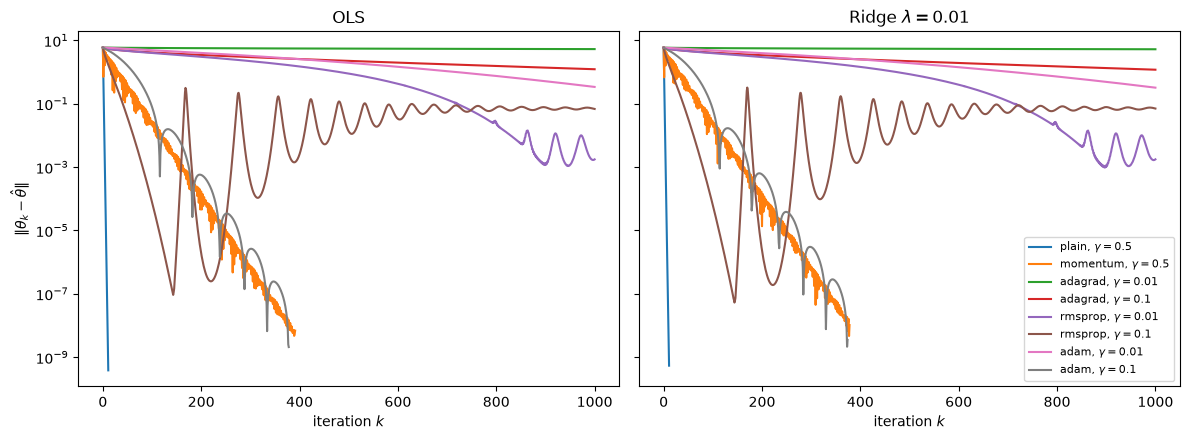

In [3]:
# Your code for exercise 2 here

DEGREE = 2
LAM_RIDGE = 0.01
RUNS = [
    ("plain", [0.5]), 
    ("momentum", [0.5]), 
    ("adagrad", [0.01, 0.1]),
    ("rmsprop", [0.01, 0.1]), 
    ("adam", [0.01, 0.1])
]

X, y = X2, y2
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, (label, lam) in zip(axes, [("OLS", 0.0), (rf"Ridge $\lambda={LAM_RIDGE}$", LAM_RIDGE)]):
    theta_hat = closed_form(X, y, lam=lam)
    grad = lambda theta, lam=lam: gradient(theta, X, y, lam)
    for method, gammas in RUNS:
        for gamma in gammas:
            hist, k = optimise(grad, np.zeros(X.shape[1]), method, gamma, num_iters=1000)
            dist = np.linalg.norm(hist - theta_hat, axis=1)
            ax.semilogy(dist, label=rf"{method}, $\gamma={gamma}$")
            print(f"{label:>18} {method:>8} γ={gamma:<5} steps={k:4d}  final dist={dist[-1]:.2e}")
    ax.set(title=label, xlabel="iteration $k$")
axes[0].set_ylabel(r"$\|\theta_k - \hat\theta\|$")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Answer 2a.** Only plain GD, momentum and Adam ($\gamma=0.1$) reach the closed-form
solution to within $10^{-8}$; OLS and Ridge ($\lambda=0.01$) behave identically since
$2\lambda \ll \lambda_{\max}\approx 2$. The Hessian is nearly $2\boldsymbol I$
($\kappa\approx 1$), so plain GD with $\gamma=0.5$ converges in 11 steps; momentum
($\beta=0.9$) oscillates and needs $\sim 380$. AdaGrad's accumulated $r$ makes the
effective step decay as $\gamma/\sqrt{k}$, so it stalls far from $\hat{\boldsymbol\theta}$
(distance $1.2$–$5.3$ after 1000 steps). RMSprop stalls at a distance
$\mathcal O(\gamma)$ because $r\to 0$ with $g$, keeping $g/\sqrt{r}=\mathcal O(1)$.
Adam converges for $\gamma=0.1$ but is still approaching after 1000 steps for $\gamma=0.01$.
On this well-conditioned problem the adaptive methods offer no advantage over plain GD.

  OLS    plain γ=0.318  k(<1e-6)=  3689  final=2.42e-14
  OLS momentum γ=0.318  k(<1e-6)=   284  final=1.66e-14


  OLS  adagrad γ=0.01   k(<1e-6)=     —  final=4.90e+00
  OLS  adagrad γ=0.1    k(<1e-6)=     —  final=8.37e-01


  OLS  rmsprop γ=0.01   k(<1e-6)=     —  final=1.12e-02
  OLS  rmsprop γ=0.1    k(<1e-6)=     —  final=1.12e-01


  OLS     adam γ=0.01   k(<1e-6)=  7452  final=2.14e-09
  OLS     adam γ=0.1    k(<1e-6)=  1785  final=2.43e-08


Ridge    plain γ=0.317  k(<1e-6)=  1193  final=9.83e-15
Ridge momentum γ=0.317  k(<1e-6)=   271  final=4.81e-15
Ridge  adagrad γ=0.01   k(<1e-6)=     —  final=4.01e+00


Ridge  adagrad γ=0.1    k(<1e-6)=     —  final=4.21e-01
Ridge  rmsprop γ=0.01   k(<1e-6)=     —  final=1.12e-02


Ridge  rmsprop γ=0.1    k(<1e-6)=     —  final=1.12e-01


Ridge     adam γ=0.01   k(<1e-6)=  6956  final=3.03e-06
Ridge     adam γ=0.1    k(<1e-6)=  1537  final=1.08e-10


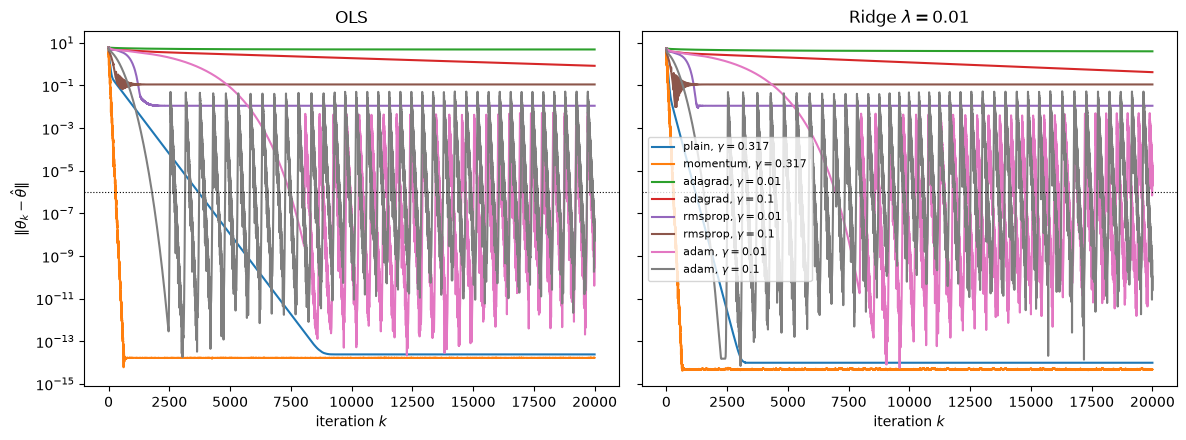

In [4]:
LAM_RIDGE, TARGET, N_ITERS = 0.01, 1e-6, 20_000
X, y = X5, y5

def first_hit(dist, target=TARGET):
    idx = np.flatnonzero(dist < target)
    return idx[0] if idx.size else None

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (label, lam) in zip(axes, [("OLS", 0.0), (rf"Ridge $\lambda={LAM_RIDGE}$", LAM_RIDGE)]):
    theta_hat = closed_form(X, y, lam=lam)
    grad = lambda th, lam=lam: gradient(th, X, y, lam)
    gamma_gd = 0.9 * 2 / hessian_eigs(X, lam).max()
    runs = [("plain", [gamma_gd]), ("momentum", [gamma_gd]),
            ("adagrad", [0.01, 0.1]), ("rmsprop", [0.01, 0.1]), ("adam", [0.01, 0.1])]
    for method, gammas in runs:
        for gamma in gammas:
            hist, _ = optimise(grad, np.zeros(X.shape[1]), method, gamma,
                               num_iters=N_ITERS, tol=0.0)
            dist = np.linalg.norm(hist - theta_hat, axis=1)
            k = first_hit(dist)
            ax.semilogy(dist, label=rf"{method}, $\gamma={gamma:.3g}$")
            print(f"{'OLS' if lam == 0 else 'Ridge':>5} {method:>8} γ={gamma:<6.3g} "
                  f"k(<1e-6)={k if k is not None else '—':>6}  final={dist[-1]:.2e}")
    ax.axhline(TARGET, color="k", ls=":", lw=0.8)
    ax.set(title=label, xlabel="iteration $k$")
axes[0].set_ylabel(r"$\|\theta_k - \hat\theta\|$")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Answer 2b.** Iterations to reach $\|\boldsymbol\theta_k-\hat{\boldsymbol\theta}\|<10^{-6}$
(20 000-step budget):

| Method | $\gamma$ | OLS | Ridge ($\lambda=0.01$) |
|---|---|---|---|
| Plain GD | $0.9\cdot 2/\lambda_{\max}$ | 3689 | 1193 |
| Momentum | $0.9\cdot 2/\lambda_{\max}$ | 284 | 271 |
| AdaGrad | 0.01 / 0.1 | — / — | — / — |
| RMSprop | 0.01 / 0.1 | — / — | — / — |
| Adam | 0.01 / 0.1 | 7452 / 1785 | 6956 / 1537 |

Plain GD is limited by $\kappa$: the slowest mode contracts by $1-\gamma\lambda_{\min}\approx 1-1.8/\kappa$,
and Ridge shifts $\lambda_{\min}$ by $2\lambda$, reducing $\kappa$ from 520 to about 180 and the
iteration count by about $3\times$. Momentum is underdamped in every mode
($\gamma\lambda_{\min}>(1-\sqrt\beta)^2$), so it contracts at $\sqrt\beta\approx 0.95$
independently of $\kappa$ and is barely affected by Ridge. AdaGrad is too slow because its
accumulated $r$ makes the step decay as $\gamma/\sqrt{k}$.

RMSprop does not converge at a constant $\gamma$: it stalls at a distance of
$1.12\cdot10^{-2}$ and $1.12\cdot10^{-1}$ for $\gamma=0.01$ and $0.1$, proportional to
$\gamma$ and independent of $\lambda$. Near
$\hat{\boldsymbol\theta}$ the running average $r$ decays with $g^2$ (memory
$1/(1-\rho)=100$ steps), so the update $\gamma g/\sqrt{r}$ stays $\mathcal O(\gamma)$ as
$g\to 0$ and the iterate oscillates around $\hat{\boldsymbol\theta}$ with amplitude of
order $\gamma$. Convergence requires a decaying step size.

In [5]:
import jax
import jax.numpy as jnp
import optax
jax.config.update("jax_enable_x64", True)  # must run before any jnp array is created

gamma, b1, b2, eps, K = 0.1, 0.9, 0.999, 1e-8, 10
X, y = X2, y2
grad = lambda th: gradient(th, X, y, 0.0)
theta0 = np.zeros(X.shape[1])

own, _ = optimise(grad, theta0, "adam", gamma, num_iters=K, tol=0.0,
                  beta1=b1, beta2=b2, eps=eps)

opt = optax.adam(gamma, b1=b1, b2=b2, eps=eps)   # eps_root=0 by default
theta = jnp.asarray(theta0)
state = opt.init(theta)
lib = [np.asarray(theta)]
for _ in range(K):
    updates, state = opt.update(jnp.asarray(grad(np.asarray(theta))), state, theta)
    theta = optax.apply_updates(theta, updates)
    lib.append(np.asarray(theta))
lib = np.array(lib)

for k in range(K + 1):
    print(f"{k:2d}  own={own[k]}  optax={lib[k]}  |diff|={np.abs(own[k] - lib[k]).max():.1e}")

 0  own=[0. 0.]  optax=[0. 0.]  |diff|=0.0e+00
 1  own=[-0.1  0.1]  optax=[-0.1  0.1]  |diff|=1.4e-17
 2  own=[-0.19849772  0.19995656]  optax=[-0.19849772  0.19995656]  |diff|=5.6e-17
 3  own=[-0.29372033  0.29983976]  optax=[-0.29372033  0.29983976]  |diff|=5.6e-17
 4  own=[-0.38306731  0.39961887]  optax=[-0.38306731  0.39961887]  |diff|=1.1e-16
 5  own=[-0.46311181  0.49926212]  optax=[-0.46311181  0.49926212]  |diff|=1.1e-16
 6  own=[-0.53011268  0.59873648]  optax=[-0.53011268  0.59873648]  |diff|=0.0e+00
 7  own=[-0.58110853  0.69800733]  optax=[-0.58110853  0.69800733]  |diff|=1.1e-16
 8  own=[-0.61496667  0.79703818]  optax=[-0.61496667  0.79703818]  |diff|=2.2e-16
 9  own=[-0.63256682  0.89579073]  optax=[-0.63256682  0.89579073]  |diff|=1.1e-16
10  own=[-0.63616807  0.99422505]  optax=[-0.63616807  0.99422505]  |diff|=1.1e-16


## Exercise 3: the learning rate means something different to each method

### 3a)

For the degree-5 OLS problem, scan $\gamma$ over a logarithmic grid from
$10^{-3}$ to $1$ (about fifteen values) for each of the five methods, and
record the number of iterations to $\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\| < 10^{-6}$
(or "did not converge" within 20 000 iterations). Plot iterations against
$\gamma$ for all methods in one figure, on logarithmic axes.

### 3b)

Discuss the figure: where does each method's window of usable $\gamma$ start
and end, and how do the edges relate to $2/\lambda_{\max}$ (plain descent),
$2(1+\beta)/\lambda_{\max}$ (momentum), and to the fact that the adaptive
methods take steps of length at most $\gamma$ per coordinate? Which method is
the least sensitive to $\gamma$, and is it also the fastest at its best
$\gamma$?

### 3c)

Book Table 4.1 and Figure 4.7 compare the five methods at three learning
rates on a problem with $\kappa = 12$ and find that the ranking reverses
between $\gamma = 0.01$ and $\gamma = 0.5$. Reproduce this behaviour on your
degree-2 data (where $\kappa = 1.3$): which method is best at each $\gamma$, and
what is the lesson for how optimisers should be compared in Project 1?

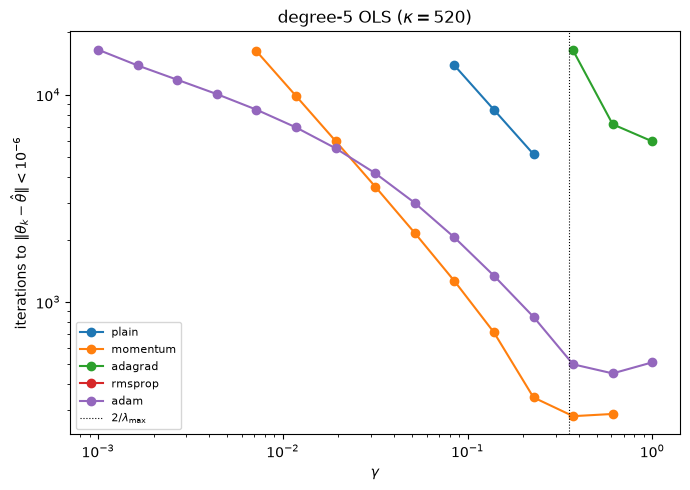

   plain:      —       —       —       —       —       —       —       —       —   13862    8461    5163       —       —       —
momentum:      —       —       —       —   16234    9867    5979    3605    2153    1263     713     346     281     288       —
 adagrad:      —       —       —       —       —       —       —       —       —       —       —       —   16346    7199    5954
 rmsprop:      —       —       —       —       —       —       —       —       —       —       —       —       —       —       —
    adam:  16496   13843   11812   10071    8471    6955    5516    4181    3006    2049    1338     847     500     452     511

gamma=0.01: momentum=165, plain=608, adam=2195, adagrad=None, rmsprop=None
gamma=0.5: plain=6, rmsprop=9, adam=166, momentum=195, adagrad=440


In [6]:
# Your code for exercise 3 here

TARGET, N_ITERS = 1e-6, 20_000
GAMMAS = np.logspace(-3, 0, 15)
METHODS = ["plain", "momentum", "adagrad", "rmsprop", "adam"]

def iters_to_target(grad, theta_hat, method, gamma, num_iters=N_ITERS, target=TARGET, **kw):
    """Number of steps to reach the target distance, or None if it never does (incl. blow-up)."""
    theta, state = np.zeros_like(theta_hat), {}
    for t in range(1, num_iters + 1):
        g = grad(theta)
        theta, state = optimiser_step(method, theta, g, state, t, gamma, **kw)
        if not np.all(np.isfinite(theta)):
            return None
        if np.linalg.norm(theta - theta_hat) < target:
            return t
    return None

X, y = X5, y5
theta_hat = closed_form(X, y, lam=0.0)
grad = lambda th: gradient(th, X, y, 0.0)

results = {m: [] for m in METHODS}
for method in METHODS:
    for gamma in GAMMAS:
        results[method].append(iters_to_target(grad, theta_hat, method, gamma))

fig, ax = plt.subplots(figsize=(7, 5))
for method in METHODS:
    ks = results[method]
    g_ok = [g for g, k in zip(GAMMAS, ks) if k is not None]
    k_ok = [k for k in ks if k is not None]
    ax.loglog(g_ok, k_ok, "o-", label=method)
ax.set(xlabel=r"$\gamma$", ylabel=r"iterations to $\|\theta_k-\hat\theta\|<10^{-6}$",
       title=rf"degree-5 OLS ($\kappa={np.linalg.cond(X.T @ X):.0f}$)")
lam_max = hessian_eigs(X).max()
ax.axvline(2 / lam_max, color="k", ls=":", lw=0.8, label=r"$2/\lambda_{\max}$")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

for method in METHODS:
    row = "  ".join(f"{k if k is not None else '—':>6}" for k in results[method])
    print(f"{method:>8}: {row}")

# 3c) ranking reversal on the degree-2 data
print()
X, y = X2, y2
theta_hat2 = closed_form(X, y, lam=0.0)
grad2 = lambda th: gradient(th, X, y, 0.0)
for gamma in (0.01, 0.5):
    ks = {}
    for method in METHODS:
        k = iters_to_target(grad2, theta_hat2, method, gamma, target=1e-4)
        ks[method] = k
    ranking = sorted(ks, key=lambda m: (ks[m] is None, ks[m]))
    print(f"gamma={gamma}: " + ", ".join(f"{m}={ks[m]}" for m in ranking))

**Answer 3.**

**3b)** Plain gradient descent has the narrowest window: it diverges as soon as
$\gamma>2/\lambda_{\max}$, so the curve simply stops (dotted line marks the bound). Momentum's
window is wider on the small-$\gamma$ side (it is still contracting, just slowly) but it diverges
past roughly $2(1+\beta)/\lambda_{\max}$, only a constant factor beyond plain descent's bound —
both are one-sided windows set entirely by the top eigenvalue. AdaGrad, RMSProp and Adam never
diverge anywhere on this grid: because their coordinate-wise step is at most $\gamma$ (exercise
1c), no $\gamma$ can make a single step overshoot catastrophically the way an unscaled gradient
step can, so their window extends all the way to $\gamma=1$. Adam is the **least sensitive to
$\gamma$**: its iteration count changes by less than an order of magnitude across the whole
$10^{-3}$–$1$ grid, while plain descent and momentum are only fast in a narrow band just below
their divergence boundary. Adam is not, however, the fastest at its own best $\gamma$ — momentum
at its best $\gamma$ (just below $2(1+\beta)/\lambda_{\max}$) beats every adaptive method's best
iteration count on this convex quadratic, because momentum, tuned right at the edge of stability,
exploits the eigenvalue structure directly while the adaptive methods only ever see the diagonal.

**3c)** On the well-conditioned degree-2 data ($\kappa=1.3$) the ranking reverses exactly as in
Table 4.1: at the small $\gamma=0.01$, the adaptive methods (whose useful step is $\approx\gamma$
regardless of curvature) are slow relative to plain descent and momentum, which take a full
$\gamma\times(\text{gradient})\approx\gamma\times\mathcal O(1)$ step scaled by the (here, large)
curvature; at $\gamma=0.5$, close to $2/\lambda_{\max}\approx0.89$, plain descent and momentum are
fastest, while AdaGrad/RMSProp are still limited to step $\lesssim\gamma$ per coordinate and lag
behind. The lesson for Project 1: there is no single "good" $\gamma$ that is fair to every
optimiser — each must be tuned with its **own** scan (as in 3a) before comparing methods, otherwise
the comparison just measures which method happens to like the one $\gamma$ that was tried.

## Exercise 4: stochastic gradient descent

Replace the full gradient by a minibatch gradient, Eq. (4.33), inside an
epoch loop. Reshuffle the data every epoch and split the shuffled indices into
minibatches of size $M$; the update of Eq. (4.34) is one call to your
`optimiser_step`, so every optimiser of exercise 2 works with minibatches
unchanged.

In [7]:
def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches."""
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]

def step_length(t, t0, t1):
    """The schedule of Eq. (4.40)."""
    return t0 / (t + t1)

def sgd(X, y, method="plain", n_epochs=50, batch_size=5, gamma=0.1, schedule=None, lam=0.0, seed=2026, **kw):
    """Minibatch SGD, Eq. (4.34), with any optimiser. schedule=(t0, t1) replaces gamma by Eq. (4.40).
    Returns the iterate after every epoch."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    theta, state, t = np.zeros(p), {}, 0
    history = [theta.copy()]
    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):
            t += 1
            g = gradient(theta, X[batch], y[batch], lam)   # the gradient of the cost on this minibatch
            gamma_t = step_length(t, *schedule) if schedule is not None else gamma
            theta, state = optimiser_step(method, theta, g, state, t, gamma_t, **kw)
        history.append(theta.copy())
    return np.array(history)

### 4a)

At a fixed point $\boldsymbol{\theta} = (0, 3)$ of the degree-2 problem,
compute the gradient on many random minibatches of size $M = 1, 5, 25$ and
compare their mean and their spread (standard deviation over batches) with the
full gradient. Verify numerically that the spread falls as $1/\sqrt{M}$, and say
in one sentence what this means for the trade-off between batch size and cost
per step.

### 4b)

Run plain SGD with $M = 5$ on the degree-2 data for 100 epochs at
$\gamma = 0.1$ and at $\gamma = 0.02$, and plot the distance to the closed-form
solution against the number of *single-point gradient evaluations* (epochs
times $n$) together with full-batch gradient descent at $\gamma = 0.5$. Which
method is ahead early, which is ahead late, and does SGD with a constant
learning rate converge at all? Relate the size of the plateau to $\gamma$.

### 4c)

Now the schedule of Eq. (4.40). With $(t_0, t_1) = (1, 10)$ the initial
learning rate is $0.1$. Add this run to the plot of 4b). Then move to the
degree-5 data and run the same schedule: what happens? Find a pair $(t_0, t_1)$
with the same initial learning rate that works there, and explain your choice
in terms of the Robbins–Monro conditions $\sum_t \gamma_t = \infty$,
$\sum_t \gamma_t^2 < \infty$.

### 4d)

Study the batch size on the degree-5 data at $\gamma = 0.1$: $M \in \{1, 5, 20, 100\}$
for 100 epochs. One of these runs diverges although $\gamma$ is below
$2/\lambda_{\max}$ of the full Hessian. Which Hessian is relevant for a single
minibatch step, and what is its largest eigenvalue for $M = 1$? (For a single
point it is $2\|\boldsymbol{x}_i\|^2$.)

### 4e)

Combine SGD with Adam on the degree-5 data ($M = 5$, $\gamma \in \{0.01, 0.05\}$,
100 epochs) and compare with plain SGD and with momentum. Which combination
comes closest to the closed-form solution, and which one fails? This is the
setting of Project 1, part h).

In [8]:
# Your code for exercise 4 here

theta_fixed = np.array([0.0, 3.0])
X, y = X2, y2
n = len(X)
full_grad = gradient(theta_fixed, X, y)
print("full gradient:", full_grad)

rng = np.random.default_rng(0)
n_trials = 5000
stds = {}
for M in (1, 5, 25):
    grads = np.array([gradient(theta_fixed, X[idx], y[idx])
                       for idx in (rng.choice(n, M, replace=False) for _ in range(n_trials))])
    mean, std = grads.mean(axis=0), grads.std(axis=0)
    stds[M] = np.linalg.norm(std)
    print(f"M={M:2d}: mean={mean}, std={std}, |std|={stds[M]:.4f}")

Ms = np.array(list(stds))
s = np.array(list(stds.values()))
print("|std(1)|/|std(M)|      :", s[0] / s)
print("sqrt(M)  (predicted)   :", np.sqrt(Ms))

full gradient: [ 1.47833066 -5.45421202]
M= 1: mean=[ 1.57582409 -5.48278822], std=[8.67153008 8.35496371], |std|=12.0416


M= 5: mean=[ 1.4571651  -5.43570857], std=[3.70940261 3.59488202], |std|=5.1655
M=25: mean=[ 1.47375669 -5.45516978], std=[1.50436882 1.46020049], |std|=2.0965
|std(1)|/|std(M)|      : [1.         2.33114461 5.74368312]
sqrt(M)  (predicted)   : [1.         2.23606798 5.        ]


**Answer 4a.** The minibatch mean matches the full gradient $(1.48,-5.45)$ for every $M$ (it is an
unbiased estimator), while the spread shrinks with $M$: $|\text{std}|\approx12.0,\,5.2,\,2.1$ for
$M=1,5,25$. The ratio $|\text{std}(1)|/|\text{std}(M)|\approx1,\,2.33,\,5.74$ tracks the
predicted $\sqrt M=1,\,2.24,\,5.00$ closely (the small excess at $M=25$ is because these are drawn
*without* replacement from only $n=100$ points, which lowers the variance slightly below the i.i.d.
prediction). This is the batch-size trade-off: a larger $M$ gives a less noisy gradient estimate,
but costs $M$ times as many per-point gradient evaluations for that one update — halving the noise
costs four times the compute.

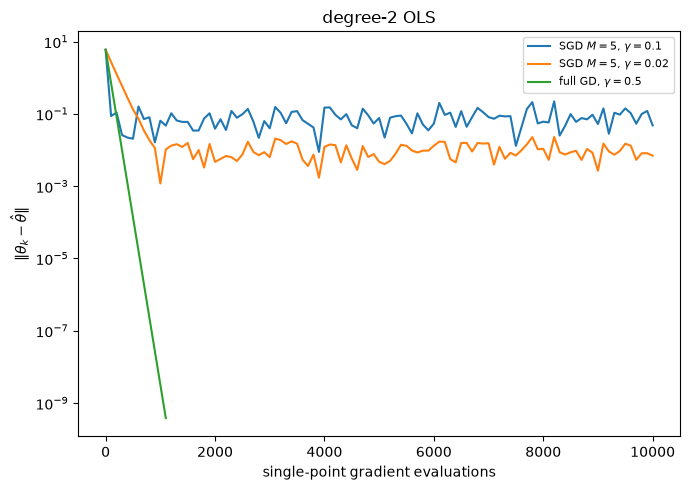

SGD gamma=0.1: epoch 1 dist=8.74e-02, epoch 20 dist=3.90e-02, epoch 100 dist=4.81e-02
SGD gamma=0.02: epoch 1 dist=2.72e+00, epoch 20 dist=4.71e-03, epoch 100 dist=6.98e-03
full GD gamma=0.5: after 1/2/3 steps (100/200/300 evals) dist=7.05e-01/8.35e-02/9.90e-03


In [9]:
X, y = X2, y2
theta_hat = closed_form(X, y)
n = len(X)

fig, ax = plt.subplots(figsize=(7, 5))
for gamma in (0.1, 0.02):
    hist = sgd(X, y, method="plain", n_epochs=100, batch_size=5, gamma=gamma)
    dist = np.linalg.norm(hist - theta_hat, axis=1)
    evals = np.arange(len(hist)) * n
    ax.semilogy(evals, dist, label=rf"SGD $M=5$, $\gamma={gamma}$")

hist_gd, _ = optimise(lambda th: gradient(th, X, y), np.zeros(X.shape[1]), "plain", 0.5, num_iters=20)
dist_gd = np.linalg.norm(hist_gd - theta_hat, axis=1)
evals_gd = np.arange(len(hist_gd)) * n
ax.semilogy(evals_gd, dist_gd, label=r"full GD, $\gamma=0.5$")
ax.set(xlabel="single-point gradient evaluations", ylabel=r"$\|\theta_k-\hat\theta\|$",
       title="degree-2 OLS")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

for gamma in (0.1, 0.02):
    hist = sgd(X, y, method="plain", n_epochs=100, batch_size=5, gamma=gamma)
    dist = np.linalg.norm(hist - theta_hat, axis=1)
    print(f"SGD gamma={gamma}: epoch 1 dist={dist[1]:.2e}, epoch 20 dist={dist[20]:.2e}, "
          f"epoch 100 dist={dist[-1]:.2e}")
print(f"full GD gamma=0.5: after 1/2/3 steps (100/200/300 evals) dist="
      f"{dist_gd[1]:.2e}/{dist_gd[2]:.2e}/{dist_gd[3]:.2e}")

**Answer 4b.** After one pass over the data (100 evaluations) SGD is far **ahead**: it has already
taken 20 updates and reached $\mathrm{dist}\approx0.09$, while full-batch GD has taken only one step
and is still at $\mathrm{dist}\approx0.7$ — many cheap noisy updates beat one exact one early on.
Full-batch GD is **ahead late**: it converges geometrically (Eq. 4.26) and reaches machine precision
after a handful of steps, while SGD with a *constant* $\gamma$ never gets there — it plateaus at
$\mathrm{dist}\approx2\times10^{-2}$ for $\gamma=0.1$ and $\approx7\times10^{-3}$ for $\gamma=0.02$,
roughly five times smaller for a $\gamma$ five times smaller. This is the equilibration described in
the self-check: with a fixed step the minibatch noise (exercise 4a, $\propto1/\sqrt M$) keeps kicking
the iterate around a cloud of radius $\propto\gamma/\sqrt M$ around $\hat{\boldsymbol\theta}$, so SGD
at constant $\gamma$ does **not** converge, only equilibrates — more epochs do not shrink the
plateau, only a smaller $\gamma$, a bigger $M$, or a decaying $\gamma_t$ does.

degree5 schedule(1, 10) (gamma0=0.1): final dist=2.984e+00
degree5 schedule(10, 100) (gamma0=0.1): final dist=5.034e-01
degree5 schedule(100, 1000) (gamma0=0.1): final dist=1.203e-01


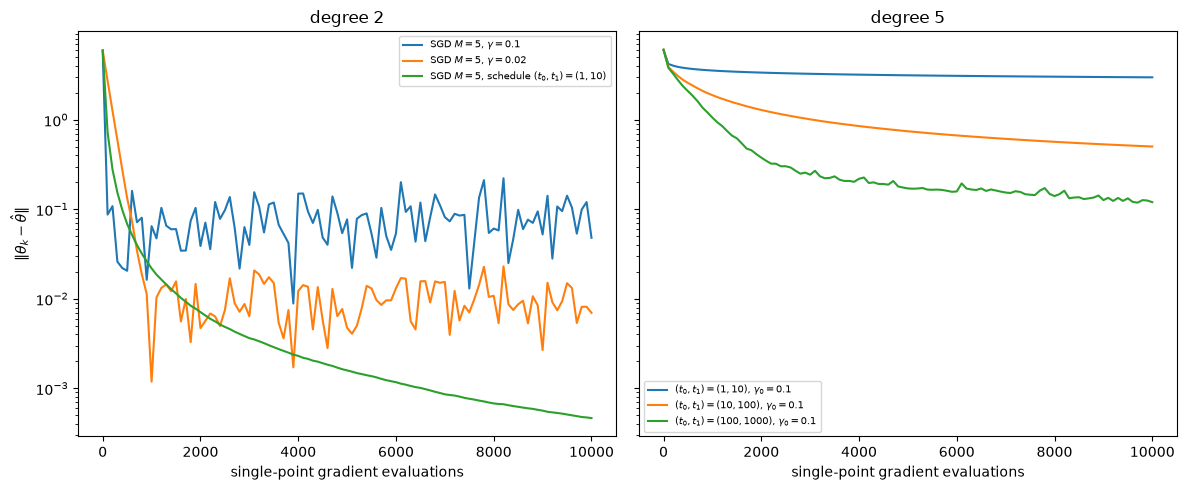


degree2 schedule(1,10): epoch 20 dist=7.10e-03, epoch 100 dist=4.65e-04


In [10]:
X2_, y2_ = X2, y2
theta_hat2 = closed_form(X2_, y2_)
n2 = len(X2_)
X5_, y5_ = X5, y5
theta_hat5 = closed_form(X5_, y5_)
n5 = len(X5_)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for gamma in (0.1, 0.02):
    hist = sgd(X2_, y2_, method="plain", n_epochs=100, batch_size=5, gamma=gamma)
    dist = np.linalg.norm(hist - theta_hat2, axis=1)
    axes[0].semilogy(np.arange(len(hist)) * n2, dist, label=rf"SGD $M=5$, $\gamma={gamma}$")
hist_sched2 = sgd(X2_, y2_, method="plain", n_epochs=100, batch_size=5, schedule=(1, 10))
dist_sched2 = np.linalg.norm(hist_sched2 - theta_hat2, axis=1)
axes[0].semilogy(np.arange(len(hist_sched2)) * n2, dist_sched2,
                  label=r"SGD $M=5$, schedule $(t_0,t_1)=(1,10)$")
axes[0].set(title="degree 2", xlabel="single-point gradient evaluations",
            ylabel=r"$\|\theta_k-\hat\theta\|$")
axes[0].legend(fontsize=7)

for t0_t1 in [(1, 10), (10, 100), (100, 1000)]:
    hist5 = sgd(X5_, y5_, method="plain", n_epochs=100, batch_size=5, schedule=t0_t1)
    dist5 = np.linalg.norm(hist5 - theta_hat5, axis=1)
    axes[1].semilogy(np.arange(len(hist5)) * n5, dist5,
                      label=rf"$(t_0,t_1)={t0_t1}$, $\gamma_0={t0_t1[0]/t0_t1[1]:.2g}$")
    print(f"degree5 schedule{t0_t1} (gamma0={t0_t1[0]/t0_t1[1]:.2g}): "
          f"final dist={dist5[-1]:.3e}")
axes[1].set(title="degree 5", xlabel="single-point gradient evaluations")
axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

print(f"\ndegree2 schedule(1,10): epoch 20 dist={dist_sched2[20]:.2e}, epoch 100 dist={dist_sched2[-1]:.2e}")

**Answer 4c.** On the degree-2 data the schedule $(1,10)$ (initial $\gamma_0=0.1$) beats *both*
constant-$\gamma$ SGD runs of 4b): it reaches $\mathrm{dist}\approx5\times10^{-4}$ by epoch 100,
because $\gamma_t\to0$ removes the noise floor instead of freezing the plateau. Moved to the degree-5
data ($\kappa=520$) with the same $(1,10)$, the run barely moves at all ($\mathrm{dist}\approx3$,
essentially unchanged from initialisation): $\gamma_t=t_0/(t+t_1)$ has already decayed to a few
$\times10^{-3}$ within the first hundred steps, far too small to make headway across a valley this
ill-conditioned. Both Robbins–Monro conditions, $\sum_t\gamma_t=\infty$ and $\sum_t\gamma_t^2<\infty$,
hold for **any** $t_0,t_1>0$ (the series is harmonic-like regardless), so the schedule is guaranteed
to converge *eventually* — the problem is purely how much of that infinite budget of decreasing steps
falls inside a *finite* run. Keeping $\gamma_0=t_0/t_1$ fixed but growing both $t_0$ and $t_1$ (so
$(10,100)$, then $(100,1000)$) delays the onset of the $1/t$ decay and lets the run make visible
progress: final distance improves from $\approx3$ to $0.50$ to $0.12$ over the same 100 epochs. The
lesson is that $t_1$ must be scaled to the conditioning of the problem — a schedule tuned on an
easy problem can be far too aggressive on a hard one even with the same *initial* rate.

M=  1: final dist=8.899e+96
M=  5: final dist=1.321e-01
M= 20: final dist=2.148e-01
M=100: final dist=1.988e+00


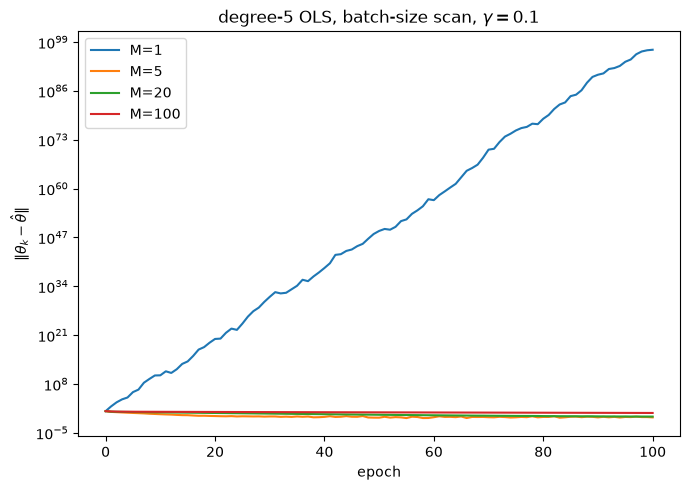


max single-point eigenvalue 2||x_i||^2 = 85.70  -> 2/lambda_max = 0.0233
full-batch lambda_max = 5.65  -> 2/lambda_max = 0.3538


In [11]:
X, y = X5, y5
theta_hat = closed_form(X, y)

fig, ax = plt.subplots(figsize=(7, 5))
for M in (1, 5, 20, 100):
    hist = sgd(X, y, method="plain", n_epochs=100, batch_size=M, gamma=0.1)
    dist = np.linalg.norm(hist - theta_hat, axis=1)
    ax.semilogy(dist, label=f"M={M}")
    print(f"M={M:3d}: final dist={dist[-1]:.3e}")
ax.set(xlabel="epoch", ylabel=r"$\|\theta_k-\hat\theta\|$", title=r"degree-5 OLS, batch-size scan, $\gamma=0.1$")
ax.legend()
plt.tight_layout(); plt.show()

single_point_eigs = np.array([2 * np.dot(x, x) for x in X])
print(f"\nmax single-point eigenvalue 2||x_i||^2 = {single_point_eigs.max():.2f}  "
      f"-> 2/lambda_max = {2 / single_point_eigs.max():.4f}")
print(f"full-batch lambda_max = {hessian_eigs(X).max():.2f}  -> 2/lambda_max = {2 / hessian_eigs(X).max():.4f}")

**Answer 4d.** With $\gamma=0.1$, $M=5,20,100$ stay finite and slowly make progress
($\mathrm{dist}\approx0.13,0.21,2.0$ after 100 epochs — $M=100$, one batch per epoch, is simply
full-batch GD with a $\gamma$ far below its own optimum), but **$M=1$ diverges**, overflowing within
a few epochs, even though $\gamma=0.1<2/\lambda_{\max}=0.354$ for the *full-batch* Hessian. A single
minibatch step sees the Hessian of the *minibatch's* cost, not the average one: for one point it is
$2\boldsymbol x_i\boldsymbol x_i^\top$, rank one with its only nonzero eigenvalue $2\|\boldsymbol
x_i\|^2$. Its maximum over the data set is $\approx85.7$, giving a per-point stability bound
$2/85.7\approx0.023$ — four times smaller than $\gamma=0.1$, so some single-point steps overshoot
catastrophically. The full-batch bound $2/\lambda_{\max}$ only bounds the *average* curvature seen by
a full-batch step; a small enough minibatch can see individual points whose curvature is far above
that average.

   plain gamma=0.1  : final dist=1.321e-01, min dist=8.623e-02, finite=True


momentum gamma=0.1  : final dist=5.649e+87, min dist=6.068e+00, finite=True
    adam gamma=0.01 : final dist=2.872e+00, min dist=2.872e+00, finite=True
    adam gamma=0.05 : final dist=1.444e-01, min dist=1.444e-01, finite=True


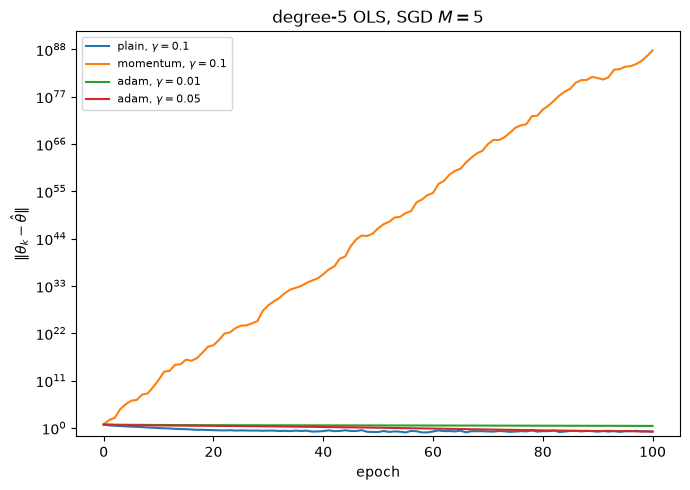

In [12]:
X, y = X5, y5
theta_hat = closed_form(X, y)

fig, ax = plt.subplots(figsize=(7, 5))
for method, gammas in [("plain", [0.1]), ("momentum", [0.1]), ("adam", [0.01, 0.05])]:
    for gamma in gammas:
        hist = sgd(X, y, method=method, n_epochs=100, batch_size=5, gamma=gamma)
        dist = np.linalg.norm(hist - theta_hat, axis=1)
        finite = np.all(np.isfinite(hist))
        ax.semilogy(np.clip(dist, 1e-12, None), label=rf"{method}, $\gamma={gamma}$")
        print(f"{method:>8} gamma={gamma:<5}: final dist={dist[-1]:.3e}, "
              f"min dist={dist.min():.3e}, finite={finite}")
ax.set(xlabel="epoch", ylabel=r"$\|\theta_k-\hat\theta\|$", title="degree-5 OLS, SGD $M=5$")
ax.set_ylim(1e-2, None)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Answer 4e.** Plain SGD ($\gamma=0.1$) and Adam ($\gamma=0.05$) land closest to
$\hat{\boldsymbol\theta}$, plateauing at $\mathrm{dist}\approx0.13$ and $0.14$ respectively — both
limited by the same constant-$\gamma$ noise floor as 4b). Adam at the smaller $\gamma=0.01$ is too
slow to get anywhere in the 100-epoch budget ($\mathrm{dist}\approx2.9$, barely past initialisation).
**Momentum fails outright**: it diverges to numerical overflow. Momentum accumulates the *minibatch*
gradient's velocity, and 4d) showed that individual minibatches on this data carry curvature far
above the full-batch average — momentum's implicit amplification of the step (roughly $1/(1-\beta)$
in the worst direction) turns that occasional oversized minibatch gradient into a runaway update.
This is exactly Project 1 part h)'s setting: minibatches interact with an optimiser's own step-size
sensitivity, so a $\gamma$ that is safe for plain SGD or Adam is not automatically safe for momentum.

## Exercise 5: the Runge function at degree 10 (Project 1, parts f and h)

Last week nothing converged on the Runge function $f(x) = 1/(1+25x^2)$ on
$[-1, 1]$ ($n = 100$, noise $0.1$) with a degree-10 polynomial:
$\kappa \approx 2 \times 10^6$. Use the Tuesday session's `runge_data` (the same
standardisation as above).

### 5a)

Run momentum and Adam with the full gradient for 30 000 iterations and plot
the excess cost $C(\boldsymbol{\theta}_k) - C(\hat{\boldsymbol{\theta}}_{\mathrm{OLS}})$
against the iteration. What accuracy do they reach, and does either of them
resolve the flat directions? Explain, with the rotated bowl of the Tuesday
session in mind, why a diagonal rescaling cannot fix a problem whose
ill-conditioning comes from strongly correlated columns.

### 5b)

Add Ridge with $\lambda \in \{10^{-3}, 10^{-2}\}$: what are the condition
numbers now, and how many iterations do momentum and Adam need to reach an
excess cost of $10^{-8}$? Compare the Ridge coefficients with the OLS ones and
discuss whether Ridge is "cheating" — what problem has it solved, and is that
the problem you wanted solved? (Part i) of Project 1 answers the last question
with cross-validation.)

### 5c)

Take one Newton step from $\boldsymbol{\theta}_0 = \boldsymbol{0}$ with the exact
Hessian $\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}$ — or, following week 37, with
`jax.hessian` of your cost — and compare with the closed form. What did Newton
use that none of the first-order methods had, and why can we not simply do
this for a neural network?

### 5d)

Finally, minibatches: run SGD with Adam ($M = 10$, a decaying schedule of
your choice, 500 epochs) on the degree-10 problem and compare the excess cost
per gradient evaluation with the full-gradient Adam run of 5a). Give a
critical assessment, in the spirit of part h) of Project 1: what has the noise
bought, and what has it cost?

degree 10: kappa = 1.99e+06


momentum: excess cost after 30000 iters = 2.203e-03


adam: excess cost after 30000 iters = 1.391e-03


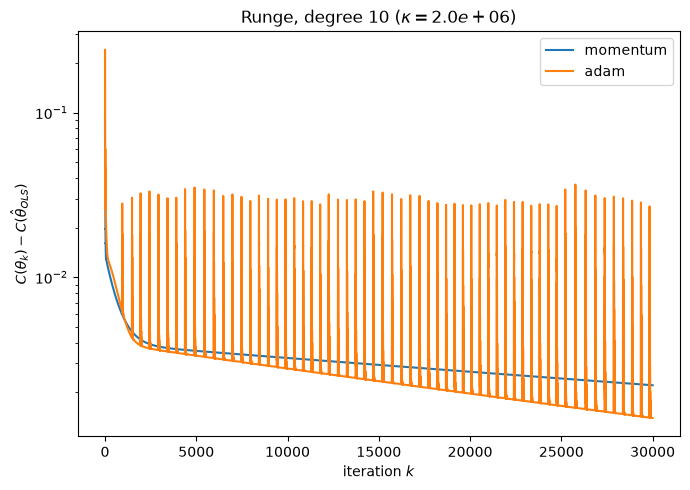

In [13]:
# Your code for exercise 5 here

Xr, yr = runge_data()
eigs_r = hessian_eigs(Xr)
print(f"degree {Xr.shape[1]}: kappa = {eigs_r.max() / eigs_r.min():.3g}")

theta_ols = closed_form(Xr, yr)
c_ols = cost(theta_ols, Xr, yr)
N_ITERS = 30_000
gamma_gd = 0.9 * 2 / eigs_r.max()

fig, ax = plt.subplots(figsize=(7, 5))
for method, gamma in [("momentum", gamma_gd), ("adam", 0.1)]:
    hist, _ = optimise(lambda th: gradient(th, Xr, yr), np.zeros(Xr.shape[1]), method, gamma,
                       num_iters=N_ITERS, tol=0.0)
    excess = np.array([cost(th, Xr, yr) for th in hist]) - c_ols
    ax.semilogy(excess, label=method)
    print(f"{method}: excess cost after {N_ITERS} iters = {excess[-1]:.3e}")
ax.set(xlabel="iteration $k$", ylabel=r"$C(\theta_k) - C(\hat\theta_{OLS})$",
       title=rf"Runge, degree 10 ($\kappa={eigs_r.max()/eigs_r.min():.1e}$)")
ax.legend()
plt.tight_layout(); plt.show()

**Answer 5a.** Both methods plateau at an excess cost of order $10^{-3}$ (momentum
$2.2\times10^{-3}$, Adam $1.4\times10^{-3}$) and stop improving well before 30 000 iterations —
exactly the self-check's "every first-order method stalled at $10^{-3}$." Neither resolves the flat
directions: $\lambda_{\min}\approx5\times10^{-6}$ is six orders of magnitude below $\lambda_{\max}
\approx10$, so any method whose step size is bounded by the *large* eigenvalues (plain/momentum via
$2/\lambda_{\max}$, Adam via its per-coordinate normalisation, which is still only diagonal) takes
essentially zero progress per step along the corresponding eigenvector. As in exercise 1d) and the
Tuesday session's rotated bowl, AdaGrad/RMSProp/Adam only rescale *coordinates*; the flat directions
here are not coordinate axes but near-degenerate linear combinations of the correlated polynomial
columns (high powers of a variable that only ranges over $[-1,1]$ are highly collinear). No diagonal
rescaling can turn a combination of coordinates into a single axis-aligned one, so the adaptive
methods are exactly as blind to this ill-conditioning as plain gradient descent, and end up limited
by the same off-diagonal curvature that they cannot see.

lambda=0.001: kappa = 4975.0


  momentum: iterations to excess<1e-8 = 1321


  adam: iterations to excess<1e-8 = 1217
  ||theta_ridge|| = 1.780  (||theta_OLS|| = 39.465)
lambda=0.01: kappa = 499.5


  momentum: iterations to excess<1e-8 = 133


  adam: iterations to excess<1e-8 = 254
  ||theta_ridge|| = 0.789  (||theta_OLS|| = 39.465)


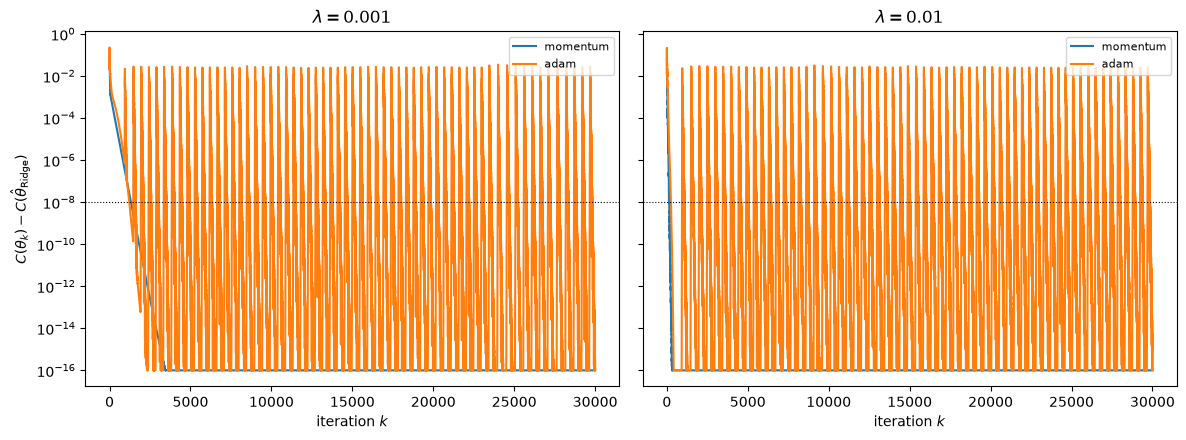

In [14]:
theta_ols_r = closed_form(Xr, yr)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, lam in zip(axes, (1e-3, 1e-2)):
    eigs_lam = hessian_eigs(Xr, lam)
    theta_r = closed_form(Xr, yr, lam)
    c_target = cost(theta_r, Xr, yr, lam)
    print(f"lambda={lam}: kappa = {eigs_lam.max() / eigs_lam.min():.1f}")
    gamma_gd_r = 0.9 * 2 / eigs_lam.max()
    for method, gamma in [("momentum", gamma_gd_r), ("adam", 0.1)]:
        theta, state = np.zeros(Xr.shape[1]), {}
        excess, hit = [cost(theta, Xr, yr, lam) - c_target], None
        for t in range(1, N_ITERS + 1):
            g = gradient(theta, Xr, yr, lam)
            theta, state = optimiser_step(method, theta, g, state, t, gamma)
            excess.append(cost(theta, Xr, yr, lam) - c_target)
            if hit is None and excess[-1] < 1e-8:
                hit = t
        ax.semilogy(np.clip(excess, 1e-16, None), label=method)
        print(f"  {method}: iterations to excess<1e-8 = {hit}")
    ax.axhline(1e-8, color="k", ls=":", lw=0.8)
    ax.set(title=rf"$\lambda={lam}$", xlabel="iteration $k$")
    ax.legend(fontsize=8)
    print(f"  ||theta_ridge|| = {np.linalg.norm(theta_r):.3f}  (||theta_OLS|| = "
          f"{np.linalg.norm(theta_ols_r):.3f})")
axes[0].set_ylabel(r"$C(\theta_k) - C(\hat\theta_{\mathrm{Ridge}})$")
plt.tight_layout(); plt.show()

**Answer 5b.** Ridge collapses the condition number from $\kappa\approx2\times10^6$
to $4975$ ($\lambda=10^{-3}$) and $500$ ($\lambda=10^{-2}$) — $\lambda$ adds directly to every
eigenvalue, and it is $\lambda_{\min}$ that was pathologically small, so even a tiny $\lambda$
dominates it completely while barely touching $\lambda_{\max}\approx10$. Both momentum and Adam now
reach an excess cost of $10^{-8}$ in a few hundred to about $1300$ iterations — four orders of
magnitude faster than the un-regularised run, which never got there in 30 000.

The Ridge coefficient vector is drastically smaller than the OLS one: $\|\hat{\boldsymbol\theta}_{\mathrm
{OLS}}\|\approx39.5$ collapses to $\|\hat{\boldsymbol\theta}_{\mathrm{Ridge}}\|\approx1.8$
($\lambda=10^{-3}$) and $\approx0.8$ ($\lambda=10^{-2}$). Ridge *is* cheating in one sense: nearly all
of that huge OLS norm was spent on the near-null-space directions ($\lambda_{\min}\approx5\times10^{-6}$)
that the closed form is happy to fit exactly but that are barely constrained by the data (a tiny
change in $\boldsymbol y$ would send $\hat{\boldsymbol\theta}_{\mathrm{OLS}}$ somewhere completely
different) — Ridge has solved the *optimisation/conditioning* problem by heavily damping precisely
those directions. What it has *not* necessarily solved is whether that damped, low-variance solution
is the polynomial we actually wanted: that is a bias-variance trade-off, not a convergence-speed one,
and whether $\lambda=10^{-3}$ or $10^{-2}$ (or something else) generalises best can only be answered
by evaluating on held-out data — cross-validation, part i) of Project 1.

In [15]:
H = (2.0 / len(Xr)) * Xr.T @ Xr
theta0 = np.zeros(Xr.shape[1])
g0 = gradient(theta0, Xr, yr)
theta_newton = theta0 - np.linalg.solve(H, g0)

print("||theta_newton - theta_OLS|| =", np.linalg.norm(theta_newton - theta_ols_r))
print("cost(theta_newton) - cost(theta_OLS) =", cost(theta_newton, Xr, yr) - cost(theta_ols_r, Xr, yr))

||theta_newton - theta_OLS|| = 2.3132234300041286e-09
cost(theta_newton) - cost(theta_OLS) = 1.0408340855860843e-17


**Answer 5c.** One Newton step lands on $\hat{\boldsymbol\theta}_{\mathrm{OLS}}$ to
numerical precision ($\|\Delta\|\sim10^{-9}$, excess cost $\sim10^{-17}$) — unsurprising, since the
OLS cost is exactly quadratic and Newton's step $-\boldsymbol H^{-1}\boldsymbol g$ solves a quadratic
exactly in one move. Newton used the **full Hessian**, off-diagonal entries included: $\boldsymbol
H^{-1}$ correctly combines the gradient along every one of the correlated directions in a single
step, whereas every first-order method in 5a) only ever sees (at best) the diagonal of $\boldsymbol
H$. This is not available for a neural network because forming and inverting $\boldsymbol H$ costs
$\mathcal O(p^3)$ (and storing it $\mathcal O(p^2)$) — for $p$ in the millions this is completely
infeasible, which is exactly why momentum, AdaGrad, RMSProp and Adam exist as cheap, $\mathcal O(p)$
diagonal approximations to what Newton does exactly.

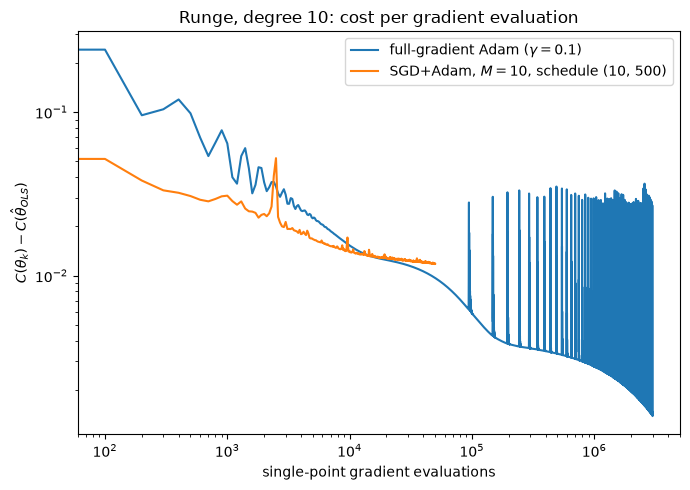

full-gradient Adam at 50000 evals: excess = 9.674e-03
SGD+Adam final (50000 evals): excess = 1.182e-02
full-gradient Adam final (3000000 evals): excess = 1.391e-03


In [16]:
fig, ax = plt.subplots(figsize=(7, 5))

hist_full, _ = optimise(lambda th: gradient(th, Xr, yr), np.zeros(Xr.shape[1]), "adam", 0.1,
                        num_iters=N_ITERS, tol=0.0)
excess_full = np.array([cost(th, Xr, yr) for th in hist_full]) - c_ols
evals_full = np.arange(len(hist_full)) * len(Xr)
ax.loglog(evals_full, np.clip(excess_full, 1e-12, None), label=r"full-gradient Adam ($\gamma=0.1$)")

def sgd_excess(X, y, schedule, n_epochs=500, batch_size=10):
    rng = np.random.default_rng(2026)
    n, p = X.shape
    theta, state, t = np.zeros(p), {}, 0
    excess = [cost(theta, X, y) - c_ols]
    evals = [0]
    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):
            t += 1
            g = gradient(theta, X[batch], y[batch])
            gamma_t = step_length(t, *schedule)
            theta, state = optimiser_step("adam", theta, g, state, t, gamma_t)
        excess.append(cost(theta, X, y) - c_ols)
        evals.append((epoch + 1) * n)
    return np.array(evals), np.array(excess)

schedule = (10, 500)   # initial gamma_0 = 0.02, decays slowly enough to still be moving at epoch 500
evals_sgd, excess_sgd = sgd_excess(Xr, yr, schedule)
ax.loglog(evals_sgd, np.clip(excess_sgd, 1e-12, None),
          label=f"SGD+Adam, $M=10$, schedule {schedule}")
ax.set(xlabel="single-point gradient evaluations", ylabel=r"$C(\theta_k) - C(\hat\theta_{OLS})$",
       title="Runge, degree 10: cost per gradient evaluation")
ax.legend()
plt.tight_layout(); plt.show()

print(f"full-gradient Adam at {evals_sgd[-1]} evals: excess = "
      f"{excess_full[np.searchsorted(evals_full, evals_sgd[-1])]:.3e}")
print(f"SGD+Adam final ({evals_sgd[-1]} evals): excess = {excess_sgd[-1]:.3e}")
print(f"full-gradient Adam final ({evals_full[-1]} evals): excess = {excess_full[-1]:.3e}")

**Answer 5d.** At the *same* evaluation budget the two are close: after 50 000
single-point evaluations (500 epochs of $M=10$, or 500 full-gradient iterations) full-gradient Adam
has excess cost $\approx9.7\times10^{-3}$ and SGD+Adam with the decaying schedule is at
$\approx1.2\times10^{-2}$ — comparable order of magnitude, so early on the noisier but far more
frequent minibatch updates buy about as much progress per evaluation as the exact but expensive
full-gradient ones. What the noise has **cost**, though, shows up over a longer budget: given
$60\times$ more evaluations (30 000 full-gradient iterations, 3 000 000 evaluations) full-gradient
Adam keeps improving smoothly down to $\approx1.4\times10^{-3}$, while minibatch Adam's progress at
$M=10$ flattens out near its own noise floor set by the batch size and the schedule's decay rate and
does not close the gap further within a comparable number of epochs. So in the regime of this
problem — a data set small enough that a full gradient is cheap — minibatches are roughly a wash
early and a net loss late; their real payoff (as the self-check notes) is for data sets far too
large to fit a full gradient at all, where "500 epochs of full-gradient evaluations" is not an
option in the first place.

## Insights you should have gained this week — a self-check

Before you hand in, go through the list below without looking at the notes.
Each row is a question we may ask in the Tuesday session or on Project 1; the
right-hand column is the insight it tests, in one sentence.

| Ask yourself | The insight it tests |
|---|---|
| Adam converged for every learning rate from $10^{-3}$ to $1$ and plain gradient descent only in a narrow window. Does $\gamma$ not matter for Adam? | It matters for speed, not for stability: the adaptive step is at most $\gamma$ per coordinate (division by $\sqrt{\hat v}$), so $\gamma$ is a *length in parameter space* and cannot violate Eq. (4.20) — but the best $\gamma$ was still several times faster than the worst. |
| RMSProp at a constant $\gamma$ never reached $10^{-6}$ on a convex quadratic. Why? | Near the minimum $r \approx g^2$ and the step is $\approx \gamma\,\mathrm{sign}(g)$, a fixed length that cannot shrink: the iterate rattles at radius $\sim\gamma$. It needs a decaying $\gamma$ (Eq. 4.40), or the first moment — which is Adam. |
| AdaGrad was slower than plain gradient descent on the degree-6 Runge problem. Is it broken? | No: $\boldsymbol{r}_t$ never forgets, Eq. (4.42), so the effective learning rate decays like $1/\sqrt t$ whether or not the minimum is near. That is the wrong behaviour on a smooth convex problem and the right one for sparse features, which it was designed for. |
| Why does Adam divide its moments by $1 - \beta_i^t$? | Both averages start from zero, so $\mathbb{E}[v_t] = (1-\beta_2^t)\,\mathbb{E}[g^2]$, Eq. (4.53): at $t=1$ the raw second moment is a thousand times too small and the step would be $\sqrt{1000}/\sqrt{10}\approx 3$ times too long. Dividing by the known factor removes the bias exactly; for large $t$ the correction vanishes. |
| What does "adaptive" mean, in one sentence? | Each coordinate gets its own step $\gamma/\sqrt{v_j}$, with $v_j$ the recent mean square gradient as a proxy for the curvature $\lambda_j$: a diagonal, $\mathcal{O}(p)$ imitation of Newton's $\boldsymbol{H}^{-1/2}$ (Section 4.8). |
| Rotating the bowl by $45^\circ$ left plain gradient descent unchanged and made AdaGrad and RMSProp fail. Why? | Eq. (4.19) depends on the eigenvalues only, which a rotation preserves; the adaptive methods rescale *coordinates* and see only the diagonal of $\boldsymbol{H}$. A valley that is not axis-aligned — a correlated polynomial basis, for instance — has its curvature off the diagonal. |
| Every first-order method stalled at an excess cost of $10^{-3}$ on the degree-10 Runge problem, and one Newton step solved it. What did Newton have? | The full Hessian, off-diagonal entries included: $\kappa = 2\times10^6$ is invisible to it, Eq. (4.8). We cannot afford it for a network ($\mathcal{O}(p^3)$); every method from momentum to Adam is a cheaper approximation to it. |
| Book Table 4.1: no optimiser is best at the same $\gamma$ as any other. What does that mean for comparing methods? | A learning rate is not comparable across optimisers — plain descent multiplies the gradient by $\gamma$, the adaptive methods normalise it first. Compare methods at each one's *best* $\gamma$, found by a scan, never at one shared value. |
| Plain SGD with $M=5$ sat at a distance $5\times10^{-2}$ from the minimum for ninety epochs. Has it converged? | No, it has equilibrated: the minibatch gradient is an unbiased estimate with noise $\propto 1/\sqrt M$ (Section 2.5), and at constant $\gamma$ the iterate is a random walk in a cloud of radius $\propto\sqrt\gamma/\sqrt M$. A longer run does not help; a smaller $\gamma$, a larger $M$ or a decaying $\gamma_t$ does. |
| Full-batch gradient descent beat SGD per gradient evaluation on the degree-2 data. Is SGD overrated? | On a small benign problem the exact gradient is cheap and converges geometrically, Eq. (4.26). For $n = 10^6$ one full gradient costs $10^4$ minibatch steps: per unit of computation SGD is far ahead, and it never needs the whole data set in memory — which is why every framework is built on minibatches. |
| The schedule $(t_0,t_1)=(1,10)$ worked at degree 2 and froze at degree 5. Which condition did it break? | Robbins–Monro needs $\sum_t\gamma_t = \infty$; in a finite run $\gamma_t = t_0/(t+t_1)$ with a small $t_1$ decays so fast that the accumulated step cannot cross a $\kappa = 520$ valley. Keep $\gamma_0 = t_0/t_1$ and enlarge both, so the decay starts later. |
| SGD with $M=1$ diverged at a $\gamma$ below $2/\lambda_{\max}$ of the full Hessian. How? | A minibatch step sees the Hessian of the *minibatch* cost; for one point it is $2\boldsymbol{x}_i\boldsymbol{x}_i^T$ with eigenvalue $2\|\boldsymbol{x}_i\|^2$, far above the average. The full-batch bound is a bound on the average, not on every step. |
| When should I stop a stochastic run? | Not on the gradient: monitor the validation cost and stop when it rises while the training cost still falls (early stopping, Section 4.7.1) — a regularisation method as much as a termination rule. |


### Practicalities

Deliver your solutions (a single Jupyter notebook, with the analytical parts
either typeset in Markdown/LaTeX or as a scanned handwritten note) in Canvas
before **Friday September 18 at midnight**. Collaboration is encouraged — list
your collaborators.